# Notebook 2 — Improved Model Training

Trains a U-Net watermark removal model with the following improvements over v1:

| Setting | v1 | v2 |
|---|---|---|
| Resolution | 128×128 | **256×256** |
| Loss | L1 + Perceptual | **L1 + Perceptual + PatchGAN** |
| SSIM metric | Global approx | **torchmetrics windowed SSIM** |
| Validation | None | **Held-out val split** |
| Augmentation | None | **Random crop + flip** |

In [ ]:
!pip install -q torch torchvision torchmetrics pillow matplotlib tqdm huggingface_hub datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.0 MB/s eta 0:00:00


In [ ]:
import os

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from datasets import load_dataset
from huggingface_hub import HfApi, login
from PIL import Image
from torch.utils.data import DataLoader, IterableDataset
from torchmetrics.functional import structural_similarity_index_measure as ssim_fn
from torchvision.models import vgg16
from tqdm import tqdm
import torchvision.transforms as T
from torch.utils.data import DataLoader, TensorDataset
import io as _io
from PIL import Image
import torch

BUFFER_SIZE = 500

In [ ]:
# ── Config
IMAGE_SIZE      = 256
BATCH_SIZE      = 8       # reduce if OOM at 256px; A100 handles 8 fine
EPOCHS          = 50      # more epochs — GAN training needs longer warm-up
LR_G            = 1e-4    # generator learning rate
LR_D            = 4e-4    # discriminator — typically 2–4× the generator lr
LAMBDA_PERC     = 0.1     # weight on perceptual loss
LAMBDA_GAN      = 0.01    # weight on GAN loss (small to avoid instability early)
CHECKPOINT_DIR  = "checkpoints_v2"
MODEL_REPO_ID   = "GeraldNdawula/Watermark_Removal_UNet_v2"
DATASET_REPO_ID = "GeraldNdawula/Watermark_Dataset_v2"
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("Device:", DEVICE)
print(f"Image size: {IMAGE_SIZE}×{IMAGE_SIZE}, batch: {BATCH_SIZE}")

Device: cuda
Image size: 256×256, batch: 8


In [ ]:
# ── Dataset
# Strategy: stream from HuggingFace ONCE at the start of each epoch into a
# fixed-size RAM buffer, then shuffle and iterate over the buffer.

import io as _io
import random as _random
from torch.utils.data import TensorDataset
import torchvision.transforms as T
from torch.utils.data import DataLoader, TensorDataset
import io as _io
from PIL import Image
import torch

BUFFER_SIZE = 500   # rest of your cell continues unchanged...

BUFFER_SIZE = 500   # pairs held in RAM per epoch

base_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])


def _to_pil(value):
    """
    Robustly convert whatever HuggingFace hands back to a PIL image.
    Streaming Parquet datasets may return:
      - a PIL Image  (HF auto-decoded)
      - a dict like {'bytes': b'...', 'path': '...'}  (Image feature)
      - raw bytes
    """
    if isinstance(value, Image.Image):
        return value
    if isinstance(value, dict):
        raw = value.get('bytes') or value.get('data')
        if raw:
            return Image.open(_io.BytesIO(raw))
        path = value.get('path')
        if path:
            return Image.open(path)
    if isinstance(value, (bytes, bytearray)):
        return Image.open(_io.BytesIO(value))
    raise TypeError(f"Cannot convert type {type(value)} to PIL Image")


def _augment_pair(clean_pil, wm_pil):
    """Consistent augmentation applied to both images in a pair."""
    if torch.rand(1).item() > 0.5:
        clean_pil = T.functional.hflip(clean_pil)
        wm_pil    = T.functional.hflip(wm_pil)
    if torch.rand(1).item() > 0.5:
        crop_size = int(IMAGE_SIZE * 0.875)
        i, j, h, w = T.RandomCrop.get_params(clean_pil, (crop_size, crop_size))
        clean_pil = T.functional.resized_crop(clean_pil, i, j, h, w, (IMAGE_SIZE, IMAGE_SIZE))
        wm_pil    = T.functional.resized_crop(wm_pil,   i, j, h, w, (IMAGE_SIZE, IMAGE_SIZE))
    return clean_pil, wm_pil


def load_buffer(split, n=BUFFER_SIZE, augment=False):
    """
    Stream exactly `n` pairs from HuggingFace into two stacked tensors.
    Returns a TensorDataset(wm_tensors, clean_tensors) ready for DataLoader.
    Shows a tqdm bar so you can see the download making progress.
    """
    ds = load_dataset(DATASET_REPO_ID, split=split, streaming=True)
    wm_list, clean_list = [], []

    print(f"Buffering {n} pairs from '{split}' split...", flush=True)
    for sample in tqdm(ds, total=n, leave=False):
        try:
            clean_pil = _to_pil(sample["clean_image"]).convert("RGB")
            wm_pil    = _to_pil(sample["watermarked_image"]).convert("RGB")
        except Exception as e:
            print(f"Skipping malformed sample: {e}")
            continue

        if augment:
            clean_pil, wm_pil = _augment_pair(clean_pil, wm_pil)

        clean_list.append(base_transform(clean_pil))
        wm_list.append(base_transform(wm_pil))

        if len(clean_list) >= n:
            break

    if not clean_list:
        raise RuntimeError(
            "Buffer is empty — no samples decoded. "
            "Check that your dataset has 'clean_image' and 'watermarked_image' columns."
        )

    wm_t    = torch.stack(wm_list)
    clean_t = torch.stack(clean_list)
    return TensorDataset(wm_t, clean_t)


# Pre-load validation buffer once — val never changes between epochs
VAL_BUFFER_SIZE = 200
print("Loading validation buffer (one-time)...")
val_dataset  = load_buffer("validation", n=VAL_BUFFER_SIZE, augment=False)  # ← "validation" not "val"
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=0, pin_memory=(DEVICE == "cuda"))

print(f"Val buffer ready: {len(val_dataset)} pairs")
print(f"Train buffer will load {BUFFER_SIZE} fresh pairs at the start of each epoch.")


Loading validation buffer (one-time)...
Buffering 200 pairs from 'validation' split...


Val buffer ready: 200 pairs
Train buffer will load 500 fresh pairs at the start of each epoch.


In [ ]:
# ── U-Net (generator)
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3,
                 features=(64, 128, 256, 512)):
        super().__init__()
        self.encoders = nn.ModuleList()
        self.pool     = nn.MaxPool2d(2)
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f))
            ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = features[-1] * 2
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(ch, f, 2, stride=2))
            self.decoders.append(DoubleConv(f * 2, f))
            ch = f

        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for up, dec, skip in zip(self.upconvs, self.decoders, skips):
            x = up(x)
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            x = dec(torch.cat([skip, x], dim=1))

        return torch.tanh(self.final_conv(x))


generator = UNet().to(DEVICE)
total_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)
print(f"Generator — {total_params:,} trainable parameters")

Generator — 31,037,763 trainable parameters


In [ ]:
# ── PatchGAN discriminator
# Classifies 70×70 overlapping patches as real or fake.
# This is the same discriminator used in pix2pix.

class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()

        def block(in_ch, out_ch, normalise=True, stride=2):
            layers = [nn.Conv2d(in_ch, out_ch, 4, stride=stride, padding=1, bias=False)]
            if normalise:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(in_channels, 64,  normalise=False),
            *block(64,  128),
            *block(128, 256),   # ← was 256, 256 — fixed to 128, 256
            *block(256, 512, stride=1),
            nn.Conv2d(512, 1, 4, stride=1, padding=1),
        )

    def forward(self, watermarked, image):
        x = torch.cat([watermarked, image], dim=1)
        return self.model(x)




discriminator = PatchDiscriminator().to(DEVICE)
d_params = sum(p.numel() for p in discriminator.parameters() if p.requires_grad)
print(f"Discriminator — {d_params:,} trainable parameters")

Discriminator — 2,768,641 trainable parameters


In [ ]:
# ── Losses
class PerceptualLoss(nn.Module):
    """VGG16 features up to relu3_3 (layer index 16)."""
    def __init__(self):
        super().__init__()
        vgg = vgg16(weights="IMAGENET1K_V1").features[:16].to(DEVICE)
        for p in vgg.parameters():
            p.requires_grad_(False)
        self.vgg = vgg
        self.l1  = nn.L1Loss()

    def forward(self, pred, target):
        # Shift from [-1,1] to roughly [0,1] for VGG
        return self.l1(self.vgg((pred + 1) / 2),
                       self.vgg((target + 1) / 2))


criterion_l1   = nn.L1Loss().to(DEVICE)
criterion_perc = PerceptualLoss().to(DEVICE)
criterion_gan  = nn.BCEWithLogitsLoss().to(DEVICE)

opt_G = optim.Adam(generator.parameters(),     lr=LR_G, betas=(0.5, 0.999))
opt_D = optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.999))

# Reduce LR if val loss plateaus
sched_G = optim.lr_scheduler.ReduceLROnPlateau(opt_G, patience=5, factor=0.5)
sched_D = optim.lr_scheduler.ReduceLROnPlateau(opt_D, patience=5, factor=0.5)

print("Losses and optimisers ready.")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 226MB/s]


Losses and optimisers ready.


In [ ]:
# ── Metrics helper

def compute_psnr(pred, target, max_val=2.0):
    """PSNR for tensors in [-1, 1] (data_range = 2.0)."""
    mse = torch.mean((pred - target) ** 2)
    if mse == 0:
        return float("inf")
    return (20 * torch.log10(torch.tensor(max_val) / torch.sqrt(mse))).item()


def compute_ssim(pred, target):
    """
    Windowed SSIM via torchmetrics.
    Inputs in [-1, 1]; data_range must be set to 2.0.
    """
    return ssim_fn(pred, target, data_range=2.0).item()


print("Metrics helper ready (using torchmetrics windowed SSIM).")

Metrics helper ready (using torchmetrics windowed SSIM).


In [ ]:
# ── Training loop

history = {
    "train_loss_G": [], "train_loss_D": [], "train_l1": [], "train_perc": [],
    "val_l1": [], "val_psnr": [], "val_ssim": [],
}

PERC_EVERY = 4   # compute perceptual loss every N batches — saves ~30% time

for epoch in range(1, EPOCHS + 1):

    # ── Reload train buffer each epoch (fresh augmentation, different subset) ─
    train_dataset = load_buffer("train", n=BUFFER_SIZE, augment=True)
    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0, pin_memory=(DEVICE == "cuda"))

    # ── Train
    generator.train()
    discriminator.train()

    t_loss_G = t_loss_D = t_l1 = t_perc = 0.0
    n_batches = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]")
    for step, (wm, clean) in enumerate(loop, 1):
        wm, clean = wm.to(DEVICE), clean.to(DEVICE)

        # ── ONE generator forward pass, reused for both D and G steps
        # Using torch.no_grad here then re-enabling for G step avoids the
        # double forward pass from the original code.
        generator.eval()   # freeze BN stats for D step
        with torch.no_grad():
            fake = generator(wm)
        generator.train()

        # ── Discriminator step
        real_logits = discriminator(wm, clean)
        fake_logits = discriminator(wm, fake)   # fake already detached (no_grad)

        loss_D = 0.5 * (
            criterion_gan(real_logits, torch.ones_like(real_logits)) +
            criterion_gan(fake_logits, torch.zeros_like(fake_logits))
        )
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ── Generator step (single forward pass with grad)
        fake_grad    = generator(wm)
        fake_logits2 = discriminator(wm, fake_grad)

        loss_l1  = criterion_l1(fake_grad, clean)
        loss_gan = criterion_gan(fake_logits2, torch.ones_like(fake_logits2))

        # Perceptual loss is expensive — only compute every PERC_EVERY steps
        if step % PERC_EVERY == 0:
            loss_perc = criterion_perc(fake_grad, clean)
            t_perc   += loss_perc.item()
        else:
            loss_perc = torch.tensor(0.0, device=DEVICE)

        loss_G = loss_l1 + LAMBDA_PERC * loss_perc + LAMBDA_GAN * loss_gan

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        t_loss_G += loss_G.item()
        t_loss_D += loss_D.item()
        t_l1     += loss_l1.item()
        n_batches += 1

        loop.set_postfix(
            G=f"{loss_G.item():.4f}",
            D=f"{loss_D.item():.4f}",
            L1=f"{loss_l1.item():.4f}"
        )

    avg_G    = t_loss_G / n_batches
    avg_D    = t_loss_D / n_batches
    avg_l1   = t_l1     / n_batches
    avg_perc = t_perc   / max(n_batches // PERC_EVERY, 1)

    history["train_loss_G"].append(avg_G)
    history["train_loss_D"].append(avg_D)
    history["train_l1"].append(avg_l1)
    history["train_perc"].append(avg_perc)

    # ── Validation
    generator.eval()
    v_l1 = v_psnr = v_ssim = 0.0
    v_batches = 0

    with torch.no_grad():
        for wm, clean in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]", leave=False):
            wm, clean = wm.to(DEVICE), clean.to(DEVICE)
            pred = generator(wm)
            v_l1   += criterion_l1(pred, clean).item()
            v_psnr += compute_psnr(pred, clean)
            v_ssim += compute_ssim(pred, clean)
            v_batches += 1

    avg_val_l1   = v_l1   / v_batches
    avg_val_psnr = v_psnr / v_batches
    avg_val_ssim = v_ssim / v_batches

    history["val_l1"].append(avg_val_l1)
    history["val_psnr"].append(avg_val_psnr)
    history["val_ssim"].append(avg_val_ssim)

    sched_G.step(avg_val_l1)
    sched_D.step(avg_val_l1)

    print(
        f"Epoch {epoch:>3}/{EPOCHS} | "
        f"G {avg_G:.4f} | D {avg_D:.4f} | "
        f"L1 {avg_l1:.4f} | Perc {avg_perc:.4f} | "
        f"Val L1 {avg_val_l1:.4f} | PSNR {avg_val_psnr:.2f} dB | SSIM {avg_val_ssim:.4f}"
    )

    if epoch % 5 == 0:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch:03d}.pth")
        torch.save({
            "epoch":         epoch,
            "generator":     generator.state_dict(),
            "discriminator": discriminator.state_dict(),
            "opt_G":         opt_G.state_dict(),
            "opt_D":         opt_D.state_dict(),
            "history":       history,
        }, ckpt_path)
        print(f"  Checkpoint saved → {ckpt_path}")

print("\nTraining complete.")

Buffering 500 pairs from 'train' split...


Epoch 1/50 [val]:   0%|          | 0/25 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch   1/50 | G 0.1919 | D 0.7274 | L1 0.1731 | Perc 0.3979 | Val L1 0.0666 | PSNR 25.85 dB | SSIM 0.7606
Buffering 500 pairs from 'train' split...


Epoch 2/50 [train]: 100%|██████████| 63/63 [00:05<00:00, 11.09it/s, D=0.7259, G=0.0949, L1=0.0857]


Epoch   2/50 | G 0.1167 | D 0.7268 | L1 0.1005 | Perc 0.2951 | Val L1 0.0714 | PSNR 25.77 dB | SSIM 0.7953
Buffering 500 pairs from 'train' split...


...

Epoch  48/50 | G 0.0581 | D 0.7268 | L1 0.0441 | Perc 0.1985 | Val L1 0.0370 | PSNR 29.28 dB | SSIM 0.8920
Buffering 500 pairs from 'train' split...


Epoch 49/50 [train]: 100%|██████████| 63/63 [00:05<00:00, 11.04it/s, D=0.7248, G=0.0537, L1=0.0444]


Epoch  49/50 | G 0.0585 | D 0.7267 | L1 0.0444 | Perc 0.2028 | Val L1 0.0357 | PSNR 29.41 dB | SSIM 0.8916
Buffering 500 pairs from 'train' split...


Epoch 50/50 [train]: 100%|██████████| 63/63 [00:05<00:00, 11.11it/s, D=0.7304, G=0.0781, L1=0.0688]


Epoch  50/50 | G 0.0559 | D 0.7269 | L1 0.0422 | Perc 0.1887 | Val L1 0.0364 | PSNR 29.35 dB | SSIM 0.8893
  Checkpoint saved → checkpoints_v2/epoch_050.pth

Training complete.


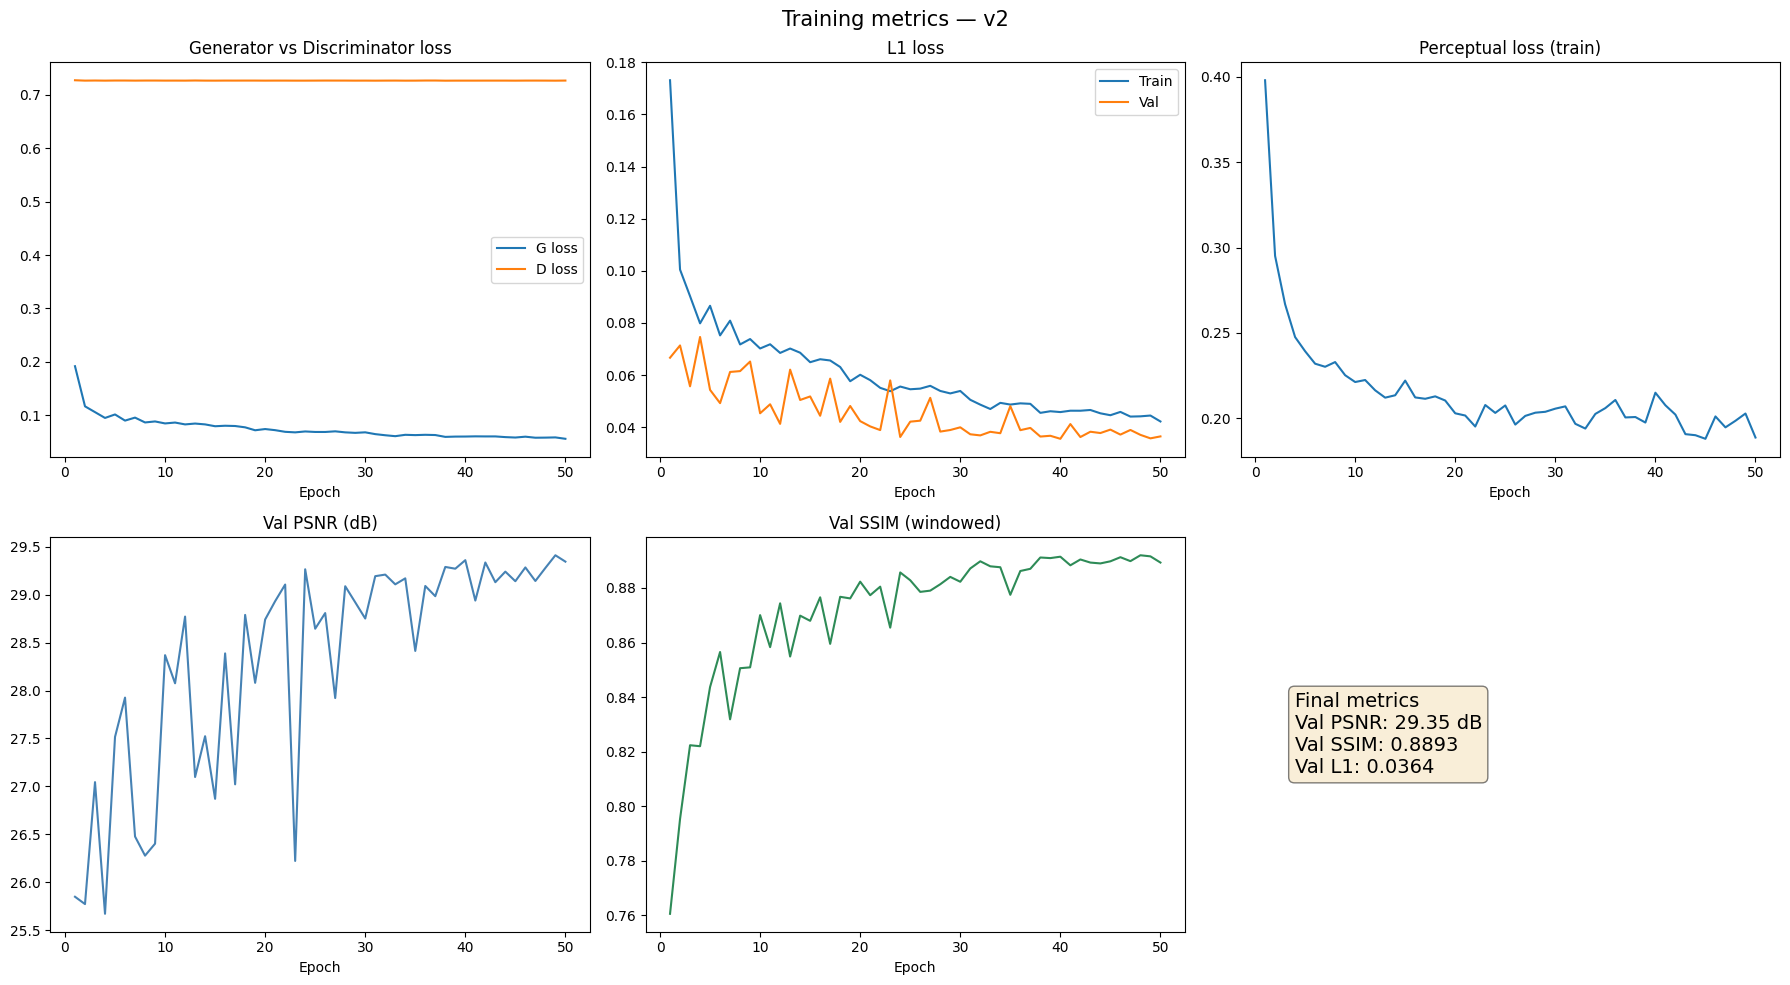

In [ ]:
# ── Plot training curves
epochs_x = range(1, len(history["train_loss_G"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0][0].plot(epochs_x, history["train_loss_G"], label="G loss")
axes[0][0].plot(epochs_x, history["train_loss_D"], label="D loss")
axes[0][0].set_title("Generator vs Discriminator loss")
axes[0][0].legend()
axes[0][0].set_xlabel("Epoch")

axes[0][1].plot(epochs_x, history["train_l1"],   label="Train")
axes[0][1].plot(epochs_x, history["val_l1"],     label="Val")
axes[0][1].set_title("L1 loss")
axes[0][1].legend()
axes[0][1].set_xlabel("Epoch")

axes[0][2].plot(epochs_x, history["train_perc"])
axes[0][2].set_title("Perceptual loss (train)")
axes[0][2].set_xlabel("Epoch")

axes[1][0].plot(epochs_x, history["val_psnr"], color="steelblue")
axes[1][0].set_title("Val PSNR (dB)")
axes[1][0].set_xlabel("Epoch")

axes[1][1].plot(epochs_x, history["val_ssim"], color="seagreen")
axes[1][1].set_title("Val SSIM (windowed)")
axes[1][1].set_xlabel("Epoch")

axes[1][2].axis("off")
final = {
    "Val PSNR":  f"{history['val_psnr'][-1]:.2f} dB",
    "Val SSIM":  f"{history['val_ssim'][-1]:.4f}",
    "Val L1":    f"{history['val_l1'][-1]:.4f}",
}
summary = "Final metrics\n" + "\n".join(f"{k}: {v}" for k, v in final.items())
axes[1][2].text(0.1, 0.5, summary, transform=axes[1][2].transAxes,
                fontsize=14, verticalalignment="center",
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.suptitle("Training metrics — v2", fontsize=15)
plt.tight_layout()
plt.savefig("metrics_v2.png", dpi=150)
plt.show()

In [ ]:
# ── Save final model and push to Hugging Face
final_path = os.path.join(CHECKPOINT_DIR, "unet_v2_final.pth")
torch.save({
    "generator":     generator.state_dict(),
    "image_size":    IMAGE_SIZE,
    "architecture":  "UNet + PatchGAN",
    "epochs":        EPOCHS,
    "history":       history,
}, final_path)
print(f"Saved → {final_path}")

login()
api = HfApi()
api.create_repo(repo_id=MODEL_REPO_ID, repo_type="model",
                exist_ok=True, private=False)

api.upload_file(
    path_or_fileobj=final_path,
    path_in_repo="unet_v2_final.pth",
    repo_id=MODEL_REPO_ID,
    repo_type="model",
    commit_message="Upload v2 final model",
)

for ckpt in sorted(os.listdir(CHECKPOINT_DIR)):
    if ckpt.endswith(".pth") and "epoch_" in ckpt:
        api.upload_file(
            path_or_fileobj=os.path.join(CHECKPOINT_DIR, ckpt),
            path_in_repo=f"checkpoints/{ckpt}",
            repo_id=MODEL_REPO_ID,
            repo_type="model",
            commit_message=f"Upload checkpoint {ckpt}",
        )

print(f"\nModel pushed → https://huggingface.co/{MODEL_REPO_ID}")

Saved → checkpoints_v2/unet_v2_final.pth


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ints_v2/unet_v2_final.pth:   0%|          |  559kB /  124MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

  checkpoints_v2/epoch_045.pth:   1%|1         | 3.91MB /  384MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  checkpoints_v2/epoch_050.pth:   2%|1         | 7.32MB /  384MB            


Model pushed → https://huggingface.co/GeraldNdawula/Watermark_Removal_UNet_v2
